Project Assignment: Dataset After Preprocessing /
Team Members:
Christian Juarez, 
Analiese Gonzalez,
Alyssa Amancio,

In [20]:
from __future__ import annotations
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
import joblib

plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.grid"] = True

# ---------- project paths ----------
def find_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "raw" / "kepler").exists():
            return p
    raise FileNotFoundError("Could not locate <repo>/data/raw/kepler")

ROOT = find_root()
RAW  = ROOT / "data" / "raw" / "kepler"
OUTD = ROOT / "results"
EDAD = OUTD / "eda"
OUTD.mkdir(exist_ok=True, parents=True)
EDAD.mkdir(exist_ok=True, parents=True)

print("ROOT:", ROOT)
print("RAW files:", [p.name for p in sorted(RAW.glob("*.csv"))])

# ---------- I/O helpers ----------
def read_csv_must(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    return pd.read_csv(path)

ROOT: /Users/chrisjuarez/CPSC483_ML_Project
RAW files: ['kepler_stellar_dr25.csv', 'kepler_stellar_dr25_supplement.csv', 'koi_cumulative.csv', 'koi_dr25.csv']


In [36]:
f_star = RAW / "kepler_stellar_dr25.csv"
f_sup  = RAW / "kepler_stellar_dr25_supplement.csv"  
f_koiC = RAW / "koi_cumulative.csv"                 
f_koiD = RAW / "koi_dr25.csv"                        

df_star = read_csv_must(f_star)
df_sup  = read_csv_must(f_sup)
df_kc   = read_csv_must(f_koiC)
df_kd   = read_csv_must(f_koiD)

# Normalize column names (lowercase)
def norm_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df

df_star = norm_cols(df_star)
df_sup  = norm_cols(df_sup)
df_kc   = norm_cols(df_kc)
df_kd   = norm_cols(df_kd)

# Ensure keys are present
assert "kepid" in df_star.columns, "kepid missing in stellar DR25"
if "kepid" not in df_sup.columns and "kepid" in df_sup.columns:
    pass  # already ok

# Overlay supplemental
df_sup_min = df_sup[["kepid"] + [c for c in df_sup.columns if c != "kepid"]].drop_duplicates("kepid")
df_star = df_star.drop_duplicates("kepid").merge(df_sup_min, on="kepid", how="left", suffixes=("", "_sup"))

# Compute nquarters if st_quarters exists (string of 0/1)
if "st_quarters" in df_star.columns:
    df_star["nquarters"] = df_star["st_quarters"].astype(str).str.count("1")
else:
    df_star["nquarters"] = np.nan

# Keep the features of interest (present-only to stay robust)
keep = [
    "kepid","teff","logg","feh","radius","mass","kepmag",
    "rrmscdpp03p0","rrmscdpp06p0","rrmscdpp12p0",
    "dataspan","dutycycle","nquarters",
    "nconfp","nkoi","ntce"
]
keep = [c for c in keep if c in df_star.columns]
df = df_star[keep].copy()

# Join KOI dispositions (optional lenient label support)
# We'll compute per-star aggregation: any CANDIDATE/CONFIRMED => positive
if {"kepid","koi_disposition"}.issubset(df_kc.columns):
    disp = df_kc[["kepid","koi_disposition"]].copy()
    disp["is_pos"] = disp["koi_disposition"].isin(["CANDIDATE","CONFIRMED"]).astype(int)
    agg  = disp.groupby("kepid", as_index=False)["is_pos"].max().rename(columns={"is_pos":"koi_pos"})
    df = df.merge(agg, on="kepid", how="left")
    df["koi_pos"] = df["koi_pos"].fillna(0).astype(int)
else:
    df["koi_pos"] = 0

# Labels:
# strict  : nconfp >= 1
# lenient : nconfp >= 1 or KOI says candidate/confirmed
df["label_strict"]  = (df.get("nconfp", 0).fillna(0) >= 1).astype(int)
df["label_lenient"] = ((df.get("nconfp",0).fillna(0) >= 1) | (df["koi_pos"]==1)).astype(int)

# Simple feature engineering (safe & numeric)
if {"feh","teff"}.issubset(df.columns):
    df["feh_x_teff"] = df["feh"] * df["teff"]
if {"radius","kepmag"}.issubset(df.columns):
    df["radius_x_kepmag"] = df["radius"] * df["kepmag"]

print(df.shape)
df.head()

(200038, 21)


,kepid,teff,logg,feh,radius,mass,kepmag,rrmscdpp03p0,rrmscdpp06p0,rrmscdpp12p0,...,dutycycle,nquarters,nconfp,nkoi,ntce,koi_pos,label_strict,label_lenient,feh_x_teff,radius_x_kepmag
0,10000785,5333,4.616,-1.00,0.650,0.635,15.749,445.410,499.980,589.300,...,0.8663,16,0,0,2,0,0,0,-5333.00,10.236850
1,10000797,6289,4.270,-0.44,1.195,0.968,13.994,80.767,60.264,45.939,...,0.8733,17,0,0,0,0,0,0,-2767.16,16.722830
2,10000800,5692,4.547,-0.04,0.866,0.965,15.379,226.348,184.595,158.220,...,0.8736,17,0,0,0,0,0,0,-227.68,13.318214
3,10000823,6580,4.377,-0.16,1.169,1.191,15.558,181.468,148.879,132.140,...,0.8734,17,0,0,0,0,0,0,-1052.80,18.187302
4,10000827,5648,4.559,-0.10,0.841,0.939,14.841,124.834,92.096,67.532,...,0.8734,17,0,0,0,0,0,0,-564.80,12.481281


In [37]:
ID_COLS   = ["kepid"]
LABELS    = ["label_lenient","label_strict"]
SPLIT_COL = None            # you can assign a split later if you want

def num_cols(frame: pd.DataFrame) -> list[str]:
    drop = set(ID_COLS + LABELS + (["koi_pos"] if "koi_pos" in frame.columns else []))
    return [c for c in frame.columns if c not in drop and pd.api.types.is_numeric_dtype(frame[c])]

def savefig(fig, name):
    for ext in ("png","pdf"):
        fig.savefig(EDAD / f"{name}.{ext}", dpi=200, bbox_inches="tight")

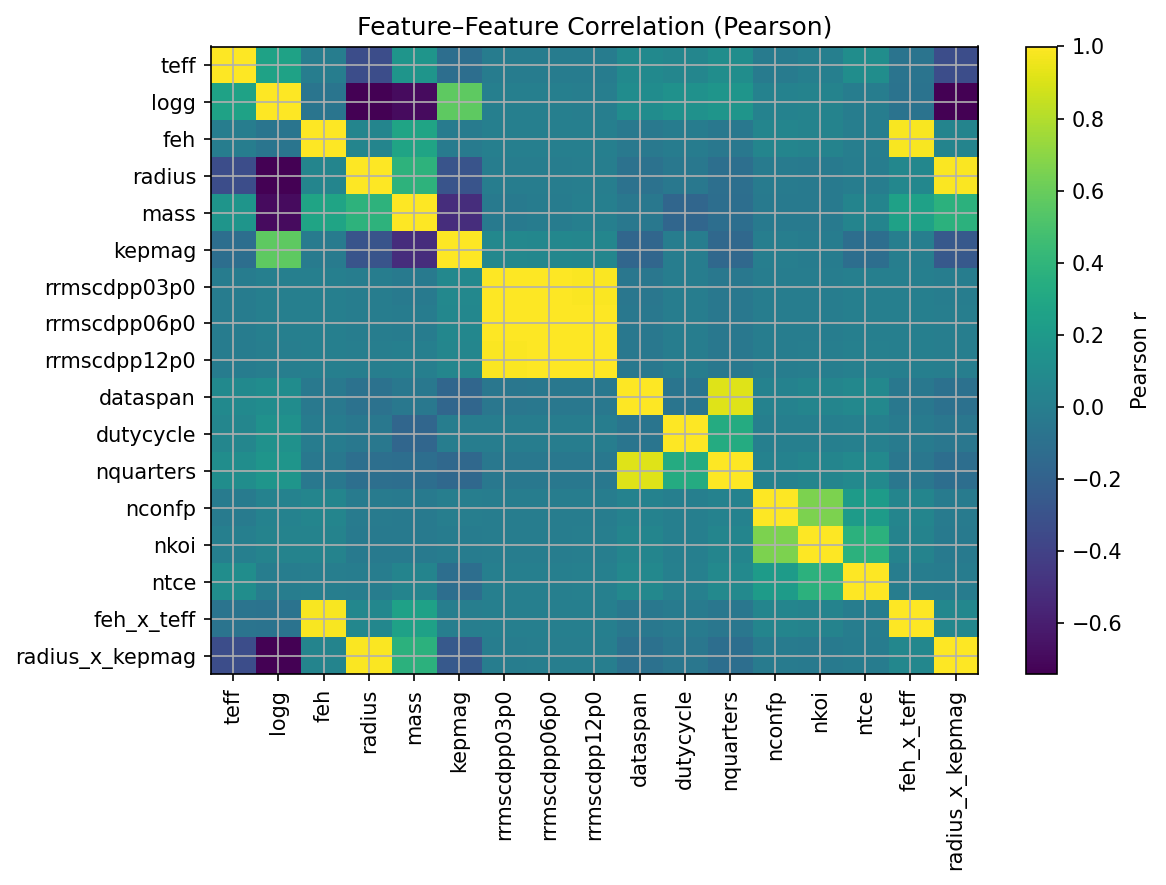

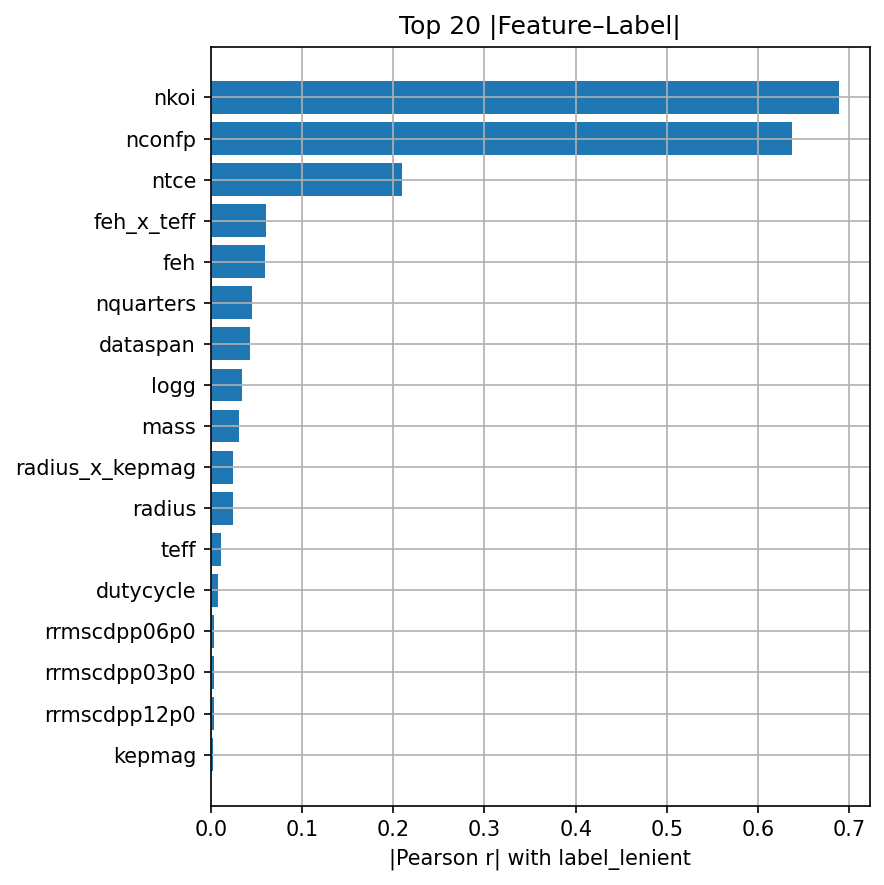

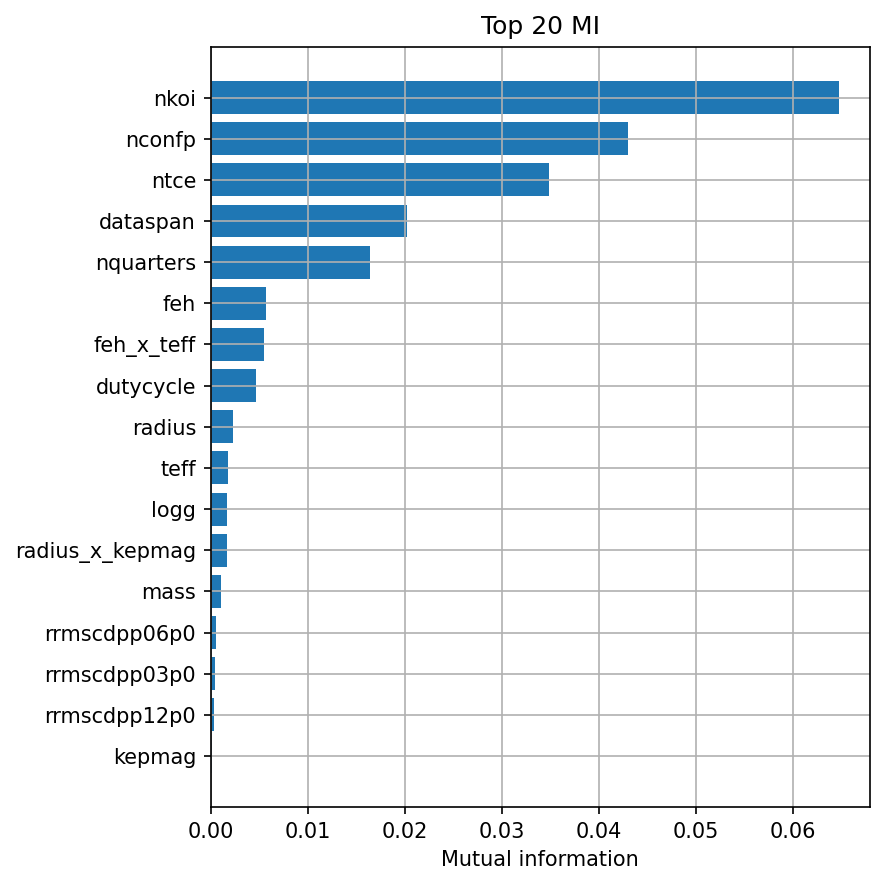

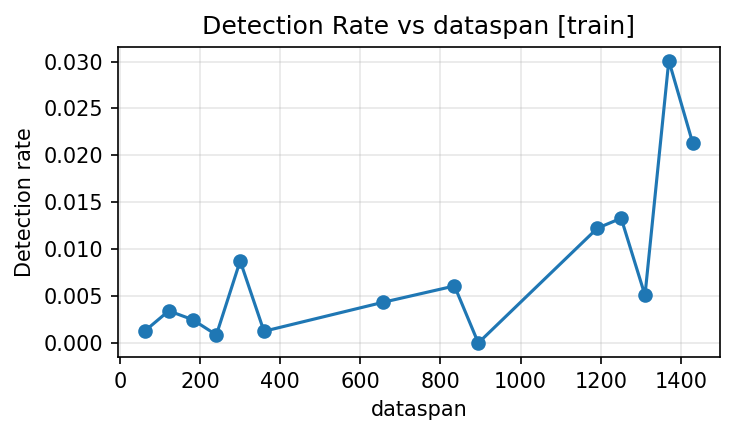

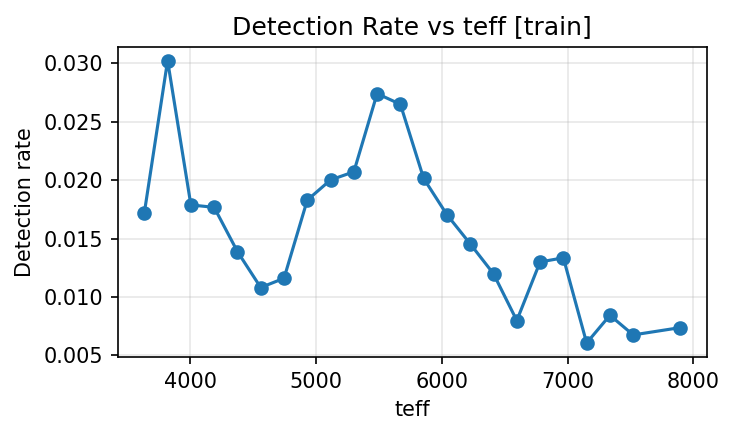

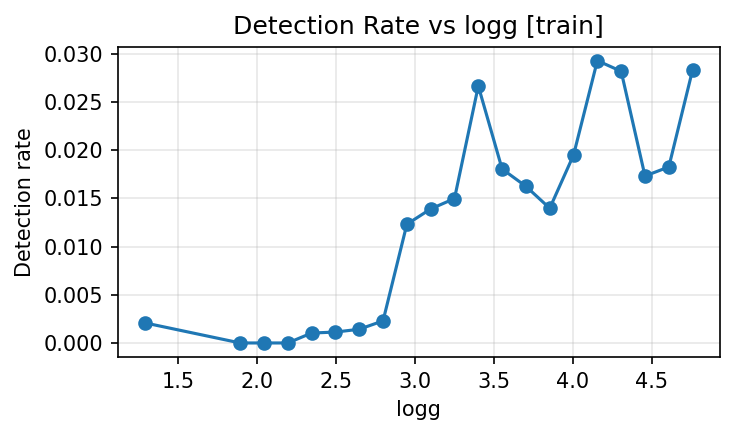

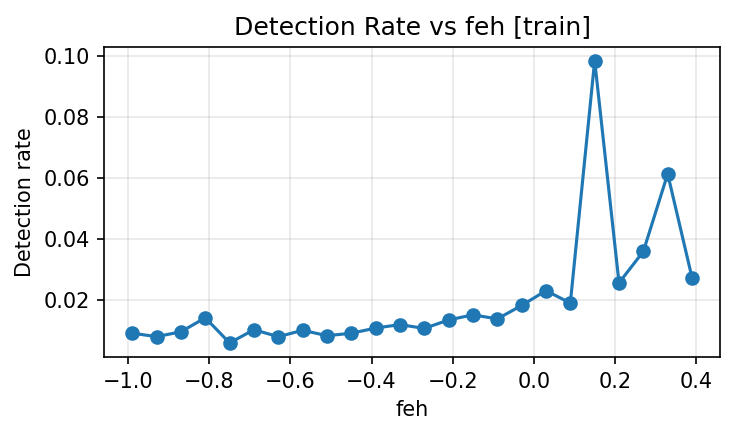

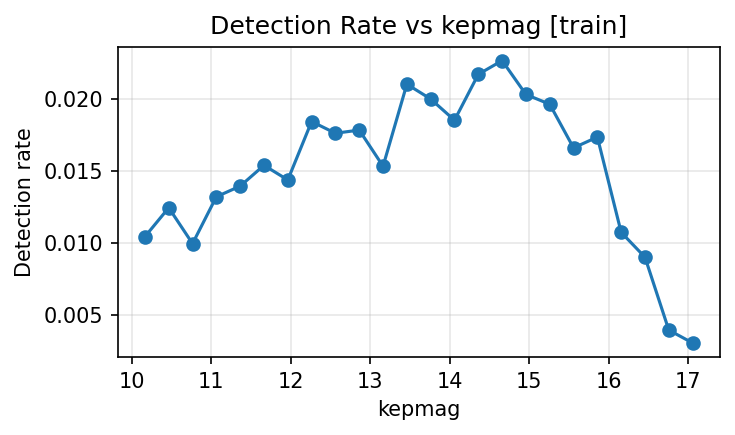

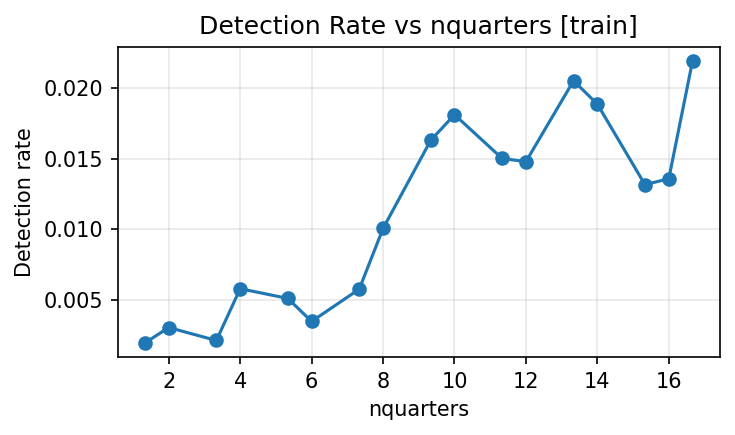

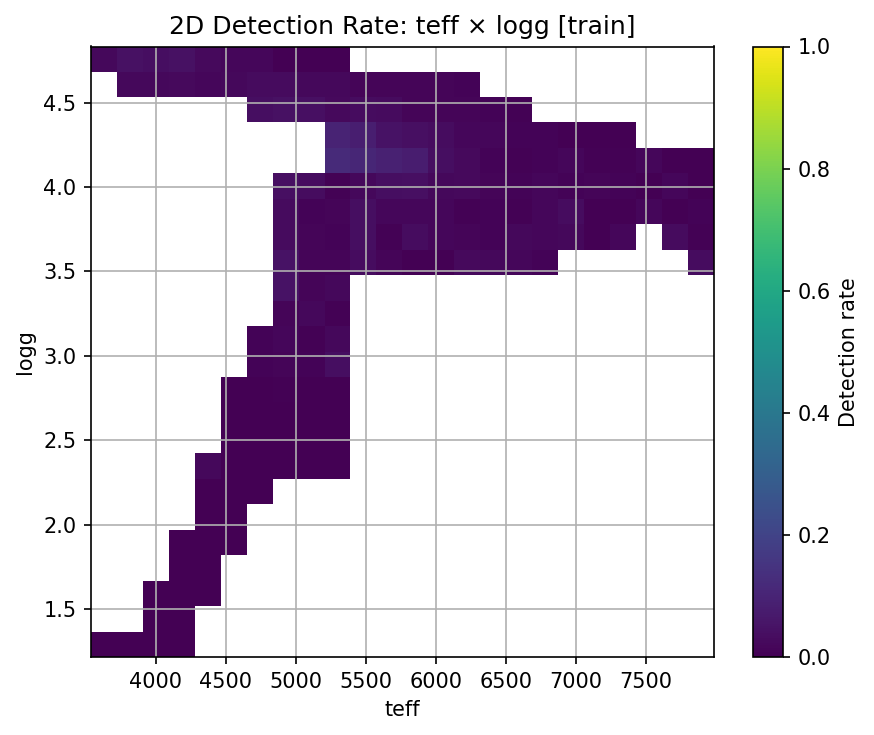

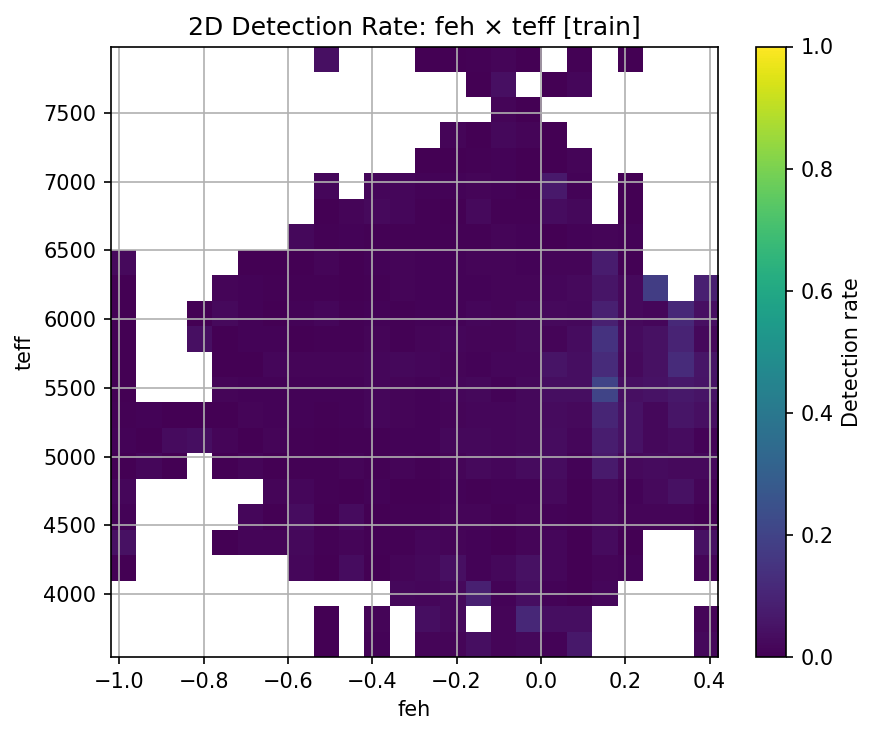

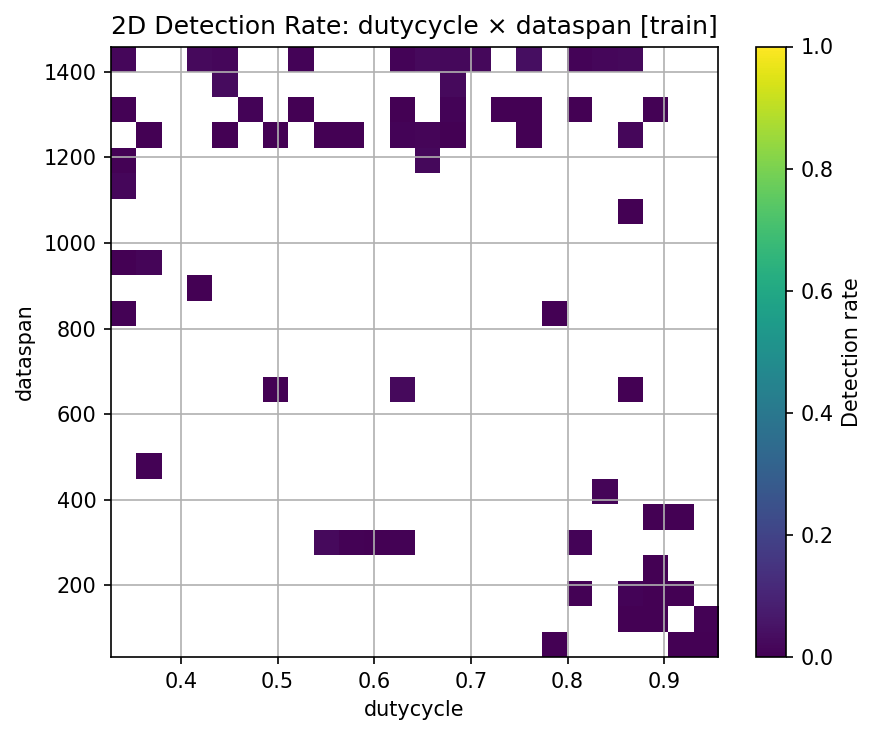

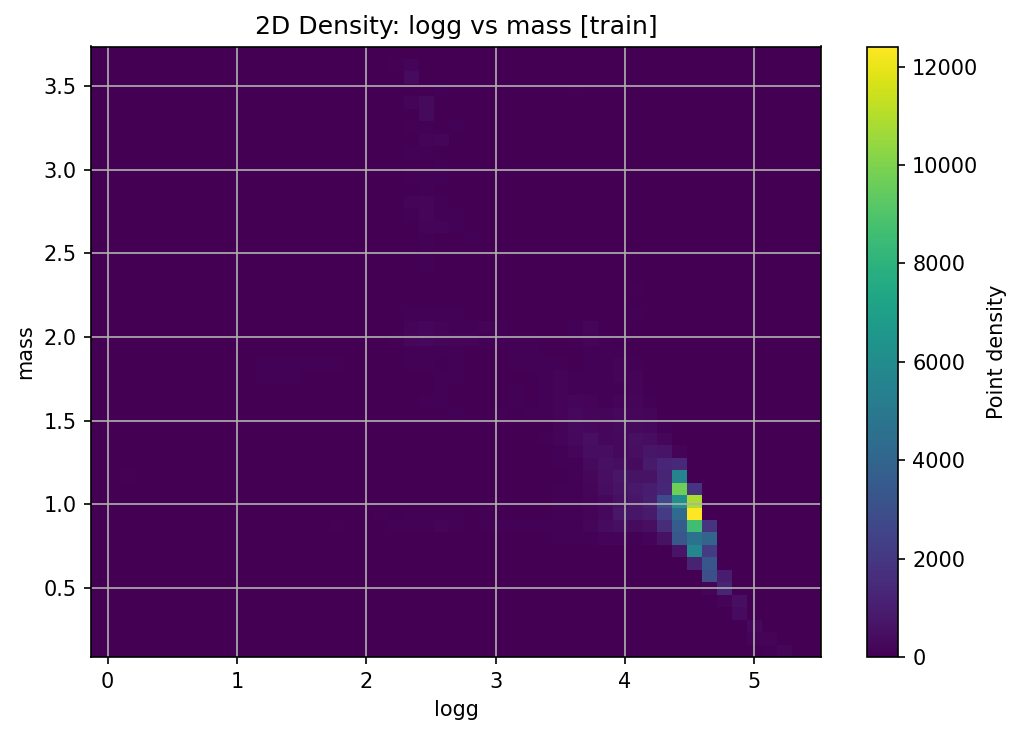

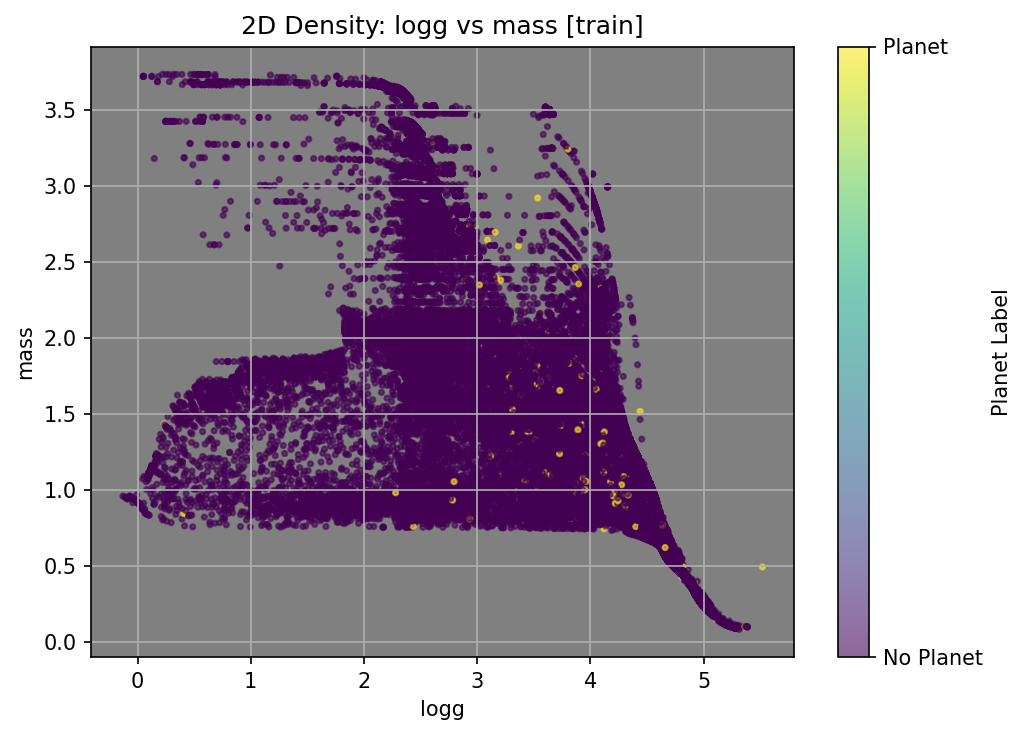

In [ ]:
features_num = num_cols(df)
label_col    = "label_lenient"

# Feature–Feature correlation
corr = df[features_num].corr(method="pearson")
fig = plt.figure(figsize=(8,6))
plt.imshow(corr.values, aspect="auto", interpolation="nearest")
plt.xticks(np.arange(len(features_num)), labels=features_num, rotation=90)
plt.yticks(np.arange(len(features_num)), labels=features_num)
plt.colorbar(label="Pearson r")
plt.title("Feature–Feature Correlation (Pearson)")
fig.tight_layout(); savefig(fig,"feature_feature_correlation"); plt.show()

# Feature–Label ranking
rows = []
y = df[label_col].astype(float).to_numpy()
for f in features_num:
    x = df[f].astype(float).to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: 
        continue
    r_p = np.corrcoef(x[m], y[m])[0,1]
    rx = pd.Series(x[m]).rank(method="average").to_numpy()
    ry = pd.Series(y[m]).rank(method="average").to_numpy()
    r_s = np.corrcoef(rx, ry)[0,1]
    rows.append((f, r_p, r_s, int(m.sum())))
corr_tbl = pd.DataFrame(rows, columns=["feature","r_pearson","r_spearman","n"]) \
           .sort_values("r_pearson", key=np.abs, ascending=False)
corr_tbl.head(20)

fig = plt.figure(figsize=(6,6))
top = corr_tbl.assign(abs_r=corr_tbl.r_pearson.abs()).nlargest(20,"abs_r").iloc[::-1]
plt.barh(top["feature"], top["abs_r"])
plt.xlabel(f"|Pearson r| with {label_col}"); plt.title("Top 20 |Feature–Label|")
fig.tight_layout(); savefig(fig,"top20_abs_correlation_with_label"); plt.show()

# Mutual Information (nonlinear)
X_mi = df[features_num].copy()
X_mi = X_mi.fillna(X_mi.median(numeric_only=True))
mi = mutual_info_classif(X_mi.values, df[label_col].values, random_state=42, discrete_features=False)
mi_tbl = pd.DataFrame({"feature": features_num, "mutual_information": mi}).sort_values("mutual_information", ascending=False)
mi_tbl.head(20)

fig = plt.figure(figsize=(6,6))
bar = mi_tbl.head(20).iloc[::-1]
plt.barh(bar["feature"], bar["mutual_information"])
plt.xlabel("Mutual information"); plt.title("Top 20 MI")
fig.tight_layout(); savefig(fig,"top20_mutual_information"); plt.show()

features_num = num_cols(df)
label_col    = "label_lenient"

# Discover & Visualize (Attribute Combinations)

# 1D detection rate (equal-width bins over clipped 1–99 percentiles) + min_n + train split
def det_rate_1d_equalwidth(frame, feature, label_col="label_lenient",
                           bins=24, min_n=400, split="train"):
    sub = frame if split is None or "split" not in frame else frame[frame["split"] == split]
    x = sub[feature].to_numpy()
    y = sub[label_col].astype(int).to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size == 0:
        return

    lo, hi = np.nanpercentile(x, 1), np.nanpercentile(x, 99)
    edges = np.linspace(lo, hi, bins + 1)
    idx = np.clip(np.digitize(np.clip(x, lo, hi), edges) - 1, 0, bins - 1)

    sums = np.bincount(idx, weights=y, minlength=bins)
    cnts = np.bincount(idx, minlength=bins).astype(float)
    keep = cnts >= min_n

    centers = 0.5 * (edges[:-1] + edges[1:])
    rate = np.divide(sums, cnts, out=np.full_like(cnts, np.nan), where=cnts > 0)

    fig = plt.figure(figsize=(5, 3))
    plt.plot(centers[keep], rate[keep], marker="o")
    plt.xlabel(feature); plt.ylabel("Detection rate")
    title_split = "" if split is None or "split" not in frame else f" [{split}]"
    plt.title(f"Detection Rate vs {feature}{title_split}")
    plt.grid(True, alpha=0.3)
    fig.tight_layout(); savefig(fig, f"det_rate_vs_{feature}")
    plt.show()

for feat in [c for c in ["dataspan","teff","logg","feh","kepmag","nquarters"] if c in df.columns]:
    det_rate_1d_equalwidth(df, feat, label_col, bins=24, min_n=400, split="train")

# 2D detection rate (equal-width bins; mask low-count cells)
def det_rate_2d_equalwidth(frame, f1, f2, label_col="label_lenient",
                           bins=24, min_n=50, split="train"):
    sub = frame if split is None or "split" not in frame else frame[frame["split"] == split]
    x = sub[f1].to_numpy()
    y = sub[f2].to_numpy()
    z = sub[label_col].astype(int).to_numpy()
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[m], y[m], z[m]
    if x.size == 0:
        return

    x_lo, x_hi = np.nanpercentile(x, 1), np.nanpercentile(x, 99)
    y_lo, y_hi = np.nanpercentile(y, 1), np.nanpercentile(y, 99)
    x_edges = np.linspace(x_lo, x_hi, bins + 1)
    y_edges = np.linspace(y_lo, y_hi, bins + 1)

    xi = np.clip(np.digitize(np.clip(x, x_lo, x_hi), x_edges) - 1, 0, bins - 1)
    yi = np.clip(np.digitize(np.clip(y, y_lo, y_hi), y_edges) - 1, 0, bins - 1)

    sums = np.zeros((bins, bins), dtype=float)
    cnts = np.zeros((bins, bins), dtype=float)
    for a, b, lbl in zip(xi, yi, z):
        sums[b, a] += lbl
        cnts[b, a] += 1

    rate = np.divide(sums, cnts, out=np.full_like(sums, np.nan), where=cnts > 0)
    rate[cnts < min_n] = np.nan

    fig = plt.figure(figsize=(6, 5))
    im = plt.imshow(rate, origin="lower", aspect="auto",
                    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
                    interpolation="nearest", vmin=0.0, vmax=1.0)
    cbar = plt.colorbar(im); cbar.set_label("Detection rate")
    title_split = "" if split is None or "split" not in frame else f" [{split}]"
    plt.xlabel(f1); plt.ylabel(f2); plt.title(f"2D Detection Rate: {f1} × {f2}{title_split}")
    fig.tight_layout(); savefig(fig, f"det_rate_2d_{f1}_x_{f2}")
    plt.show()

for a, b in [("teff","logg"), ("feh","teff"), ("dutycycle","dataspan")]:
    if a in df.columns and b in df.columns:
        det_rate_2d_equalwidth(df, a, b, label_col, bins=24, min_n=50, split="train")

# Density + label-colored scatter (unchanged; computed on TRAIN only if split exists)
def hist2d_counts(frame, xcol, ycol, bins=50):
    sub = frame if "split" not in frame else frame[frame["split"] == "train"]
    x = sub[xcol].to_numpy(); y = sub[ycol].to_numpy()
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    x_bins = np.linspace(np.nanmin(x), np.nanmax(x), bins)
    y_bins = np.linspace(np.nanmin(y), np.nanmax(y), bins)
    fig, ax = plt.subplots(figsize=(7,5))
    h = ax.hist2d(x, y, bins=[x_bins, y_bins])
    plt.colorbar(h[3], ax=ax, label="Point density")
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    ax.set_title(f"2D Density: {xcol} vs {ycol} [train]")
    fig.tight_layout(); savefig(fig, f"density2d_{xcol}_vs_{ycol}")
    plt.show()

def scatter_with_label(frame, xcol, ycol, label_col):
    sub = frame if "split" not in frame else frame[frame["split"] == "train"]
    x = sub[xcol].to_numpy(); y = sub[ycol].to_numpy(); c = sub[label_col].astype(int).to_numpy()
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(c); x, y, c = x[m], y[m], c[m]
    fig, ax = plt.subplots(figsize=(7,5))
    sc = ax.scatter(x, y, c=c, cmap="viridis", s=6, alpha=0.6)
    cb = plt.colorbar(sc, ax=ax, ticks=[0,1]); cb.set_ticklabels(["No Planet","Planet"]); cb.set_label("Planet Label")
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    ax.set_title(f"2D Density: {xcol} vs {ycol} [train]")
    ax.set_facecolor("grey")
    fig.tight_layout(); savefig(fig, f"scatter_label_{xcol}_vs_{ycol}")
    plt.show()

if {"logg","mass"}.issubset(df.columns):
    hist2d_counts(df, "logg", "mass")
    scatter_with_label(df, "logg", "mass", label_col)

In [35]:
# Optional stratified split on label to let you preview train/val/test distributions.
spl = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx = next(spl.split(df, df[label_col]))
train = np.zeros(len(df), dtype=bool); train[idx[0]] = True
df["split"] = np.where(train, "train", "test")
df["split"].value_counts()

split
train    160030
test      40008
Name: count, dtype: int64

In [34]:
# Separate features/target
FEATURE_COLS = num_cols(df)           # numeric features (no labels/id)
TARGET_COL   = label_col

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].astype(int).copy()

# Allow for any categorical columns that might appear in the future
cat_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
num_cols_only = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
# Check missing values in features
miss = df[FEATURE_COLS].isna().sum()
miss_tbl = (miss[miss>0].sort_values(ascending=False)
            .to_frame('missing')
            .assign(pct=lambda t: (t['missing']/len(df)).round(4)))
display(miss_tbl.head(20))
print(f"Any missing? {miss_tbl.shape[0] > 0}")

# Winsorize (clip) helper in a FunctionTransformer-like wrapper
class Winsorizer:
    def __init__(self, lower=0.001, upper=0.999):
        self.lower = lower; self.upper = upper
        self.lower_q_ = None; self.upper_q_ = None
        self.cols_ = None
    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.cols_ = X.columns.tolist()
        self.lower_q_ = X.quantile(self.lower)
        self.upper_q_ = X.quantile(self.upper)
        return self
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c in self.cols_:
            lo, hi = self.lower_q_[c], self.upper_q_[c]
            X[c] = np.clip(X[c], lo, hi)
        return X.values

num_pipe = Pipeline(steps=[
    ("impute",    SimpleImputer(strategy="median", add_indicator=True)),
    ("winsor",    Winsorizer(0.001, 0.999)),
    ("yeojohn",   PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scale",     StandardScaler(with_mean=True, with_std=True)),
])

if cat_cols:
    cat_pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe",    OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    pre = ColumnTransformer([
        ("num", num_pipe, num_cols_only),
        ("cat", cat_pipe, cat_cols),
    ])
else:
    pre = ColumnTransformer([
        ("num", num_pipe, num_cols_only),
    ])

# Fit on TRAIN rows only (to avoid leakage), transform full dataset
train_mask = (df["split"] == "train") if "split" in df.columns else np.ones(len(df), dtype=bool)
pre.fit(X[train_mask], y[train_mask])

X_proc = pre.transform(X)

# Column names after transform
num_imputer = pre.named_transformers_["num"].named_steps["impute"]
num_out = []
for c in num_cols_only:
    num_out.append(c)                               # imputed value
num_out += [f"__imp_ind_{i}" for i in range(num_imputer.indicator_.features_.shape[0])]  # indicators (approx count)

cat_out = []
if cat_cols:
    ohe = pre.named_transformers_["cat"].named_steps["ohe"]
    cat_out = ohe.get_feature_names_out(cat_cols).tolist()

col_out = num_out + cat_out
X_proc_df = pd.DataFrame(X_proc, columns=col_out, index=X.index)
print("Processed shape:", X_proc_df.shape)
X_proc_df.head()

,missing,pct
mass,2942,0.0147
rrmscdpp03p0,1336,0.0067
rrmscdpp06p0,1336,0.0067
rrmscdpp12p0,1336,0.0067
dataspan,1336,0.0067
dutycycle,1336,0.0067
kepmag,79,0.0004
radius_x_kepmag,79,0.0004


Any missing? True
Processed shape: (200038, 25)


,teff,logg,feh,radius,mass,kepmag,rrmscdpp03p0,rrmscdpp06p0,rrmscdpp12p0,dataspan,...,feh_x_teff,radius_x_kepmag,__imp_ind_0,__imp_ind_1,__imp_ind_2,__imp_ind_3,__imp_ind_4,__imp_ind_5,__imp_ind_6,__imp_ind_7
0,-0.394962,0.960787,-2.518991,-1.175181,-1.467561,1.039634,1.471630,1.902960,2.288535,0.247761,...,-2.716919,-1.027246,-0.122711,0.0,-0.081851,-0.081851,-0.081851,-0.081851,-0.081851,0.0
1,0.775627,-0.206906,-1.037442,0.087126,-0.119354,-0.357626,-0.952094,-1.122821,-1.295156,0.512878,...,-1.175634,0.050308,-0.122711,0.0,-0.081851,-0.081851,-0.081851,-0.081851,-0.081851,0.0
2,0.050855,0.688904,0.400487,-0.555962,-0.128849,0.713220,0.555430,0.562387,0.583289,0.512878,...,0.395888,-0.403246,-0.122711,0.0,-0.081851,-0.081851,-0.081851,-0.081851,-0.081851,0.0
3,1.122030,0.104841,-0.078766,0.045699,0.492081,0.868910,0.243695,0.253627,0.326754,0.512878,...,-0.124978,0.199438,-0.122711,0.0,-0.081851,-0.081851,-0.081851,-0.081851,-0.081851,0.0
4,-0.003363,0.734657,0.154731,-0.617743,-0.212776,0.269713,-0.298380,-0.461691,-0.680426,0.512878,...,0.180687,-0.546699,-0.122711,0.0,-0.081851,-0.081851,-0.081851,-0.081851,-0.081851,0.0


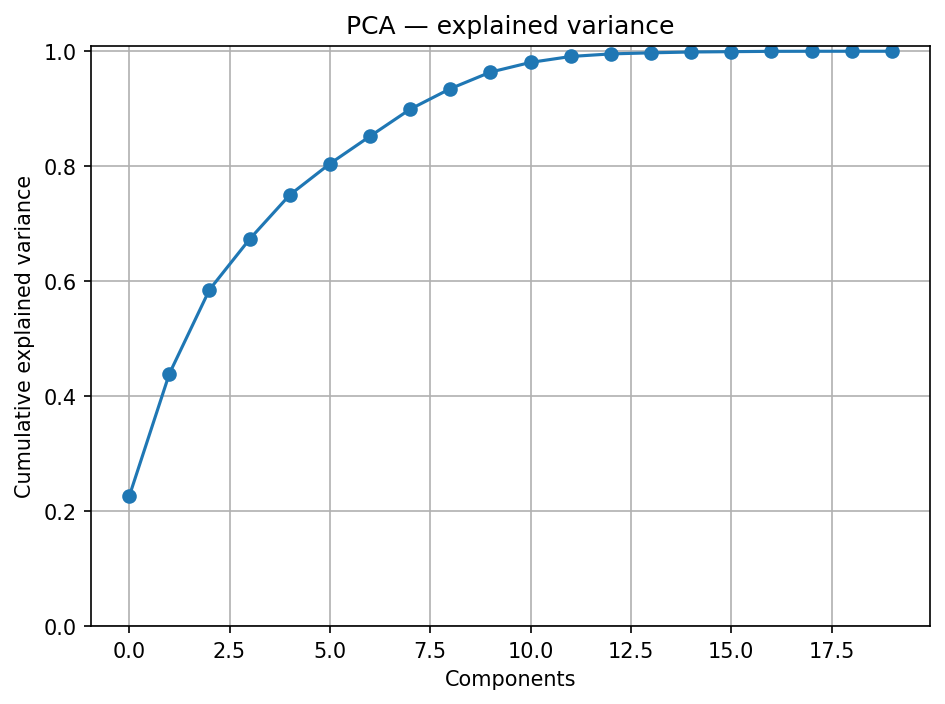

Components for 90% EV: 9


In [30]:
pca = PCA(n_components=min(20, X_proc_df.shape[1]))
pca.fit(X_proc_df)
evr = pca.explained_variance_ratio_

fig = plt.figure()
plt.plot(np.cumsum(evr), marker="o"); plt.ylim(0,1.01)
plt.xlabel("Components"); plt.ylabel("Cumulative explained variance")
plt.title("PCA — explained variance")
fig.tight_layout(); savefig(fig, "pca_explained_variance"); plt.show()

print("Components for 90% EV:", int(np.argmax(np.cumsum(evr) >= 0.90) + 1))

In [31]:
# Build final table (features + target) and save as CSV for submission
final = X_proc_df.copy()
final[label_col] = y.values

out_csv = ROOT / "data" / "processed" / "dataset_preprocessed.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
final.to_csv(out_csv, index=False)

print(f"Wrote: {out_csv}")
print(f"Shape: {final.shape} | Pos rate ({label_col}): {final[label_col].mean():.4%}")

Wrote: /Users/chrisjuarez/CPSC483_ML_Project/data/processed/dataset_preprocessed.csv
Shape: (200038, 26) | Pos rate (label_lenient): 1.8137%
